# User Base and Engagement Overview

## Objective

In this notebook, I look at the user base and basic engagement behavior.

I will focus on:

- user base size and mix
- new user trend
- session activity and playtime
- engagement differences by country, OS, and user type
- a simple user-level table for later notebooks


In [31]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

warnings.filterwarnings('ignore')
pd.options.display.float_format = '{:,.2f}'.format
plt.style.use('seaborn-v0_8-whitegrid')

## 1. Load and prepare data

I use `users` and `user_sessions` in this notebook. The cleaning step here is short because the main quality check was done in the previous notebook.


In [32]:
data_dir = Path('csv_files')

users = pd.read_csv(data_dir / 'users.csv')
sessions = pd.read_csv(data_dir / 'user_sessions.csv')

users['user_id'] = pd.to_numeric(users['user_id'], errors='coerce').astype('Int64')
users['join_date'] = pd.to_datetime(users['join_date'], errors='coerce')
users['country'] = users['country'].fillna('Unknown')

sessions['user_id'] = pd.to_numeric(sessions['user_id'], errors='coerce').astype('Int64')
sessions['dt'] = pd.to_datetime(sessions['dt'], errors='coerce')
sessions['session_id'] = pd.to_numeric(sessions['session_id'], errors='coerce').astype('Int64')
sessions['session_duration_sec'] = pd.to_numeric(sessions['session_duration_sec'], errors='coerce')
sessions['level_completed'] = pd.to_numeric(sessions['level_completed'], errors='coerce').astype('Int64')

users_clean = users.drop_duplicates(subset=['user_id']).copy()

sessions_clean = sessions[sessions['user_id'].isin(users_clean['user_id'])].copy()
sessions_clean = sessions_clean[
    sessions_clean['dt'].notna() &
    sessions_clean['session_duration_sec'].notna() &
    (sessions_clean['session_duration_sec'] >= 0)
].copy()

session_start = sessions_clean['dt'].min()
session_end = sessions_clean['dt'].max()

print(f'Session window: {session_start.date()} to {session_end.date()}')


Session window: 2022-06-02 to 2022-12-28


## 2. Scope and assumptions

- This notebook uses only `users` and `user_sessions`.
- Session metrics use valid session rows with a parsed date and a non-negative duration.
- User-level summaries use only sessions that match a `user_id` in `users`.
- I keep zero-duration sessions in the data because they may still be real events. I will only read them carefully in the comments.


## 3. User base overview

First, I want to understand who the users are and how the user base is distributed.


,metric,value
0,total users,6584
1,join date min,2021-07-09
2,join date max,2022-12-25
3,number of countries,124
4,number of OS values,2


,country,users
0,United Kingdom,1531
1,United States,1439
2,Germany,418
3,Spain,260
4,Chile,237
5,Italy,189
6,France,187
7,Poland,145
8,Canada,130
9,Brazil,121


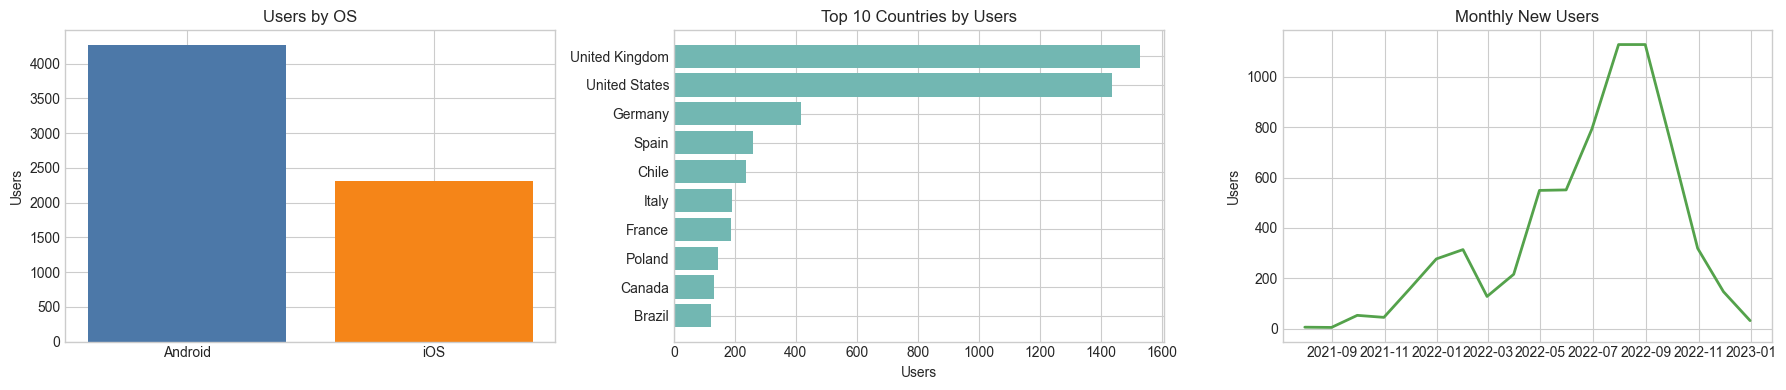

In [33]:
user_base_df = pd.DataFrame(
    {
        'metric': [
            'total users',
            'join date min',
            'join date max',
            'number of countries',
            'number of OS values',
        ],
        'value': [
            users_clean['user_id'].nunique(dropna=True),
            users_clean['join_date'].min().date(),
            users_clean['join_date'].max().date(),
            users_clean.loc[users_clean['country'] != 'Unknown', 'country'].nunique(dropna=True),
            users_clean['os'].nunique(dropna=True),
        ],
    }
)

top_countries_users = (
    users_clean['country']
    .value_counts()
    .head(10)
    .rename_axis('country')
    .reset_index(name='users')
)

os_dist = (
    users_clean['os']
    .value_counts()
    .rename_axis('os')
    .reset_index(name='users')
)

monthly_joins = (
    users_clean
    .set_index('join_date')
    .resample('ME')['user_id']
    .nunique()
    .reset_index(name='new_users')
)

display(user_base_df)
display(top_countries_users)

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

axes[0].bar(os_dist['os'], os_dist['users'], color=['#4C78A8', '#F58518'])
axes[0].set_title('Users by OS')
axes[0].set_ylabel('Users')

axes[1].barh(top_countries_users['country'][::-1], top_countries_users['users'][::-1], color='#72B7B2')
axes[1].set_title('Top 10 Countries by Users')
axes[1].set_xlabel('Users')

axes[2].plot(monthly_joins['join_date'], monthly_joins['new_users'], color='#54A24B', linewidth=2)
axes[2].set_title('Monthly New Users')
axes[2].set_ylabel('Users')

plt.tight_layout()
plt.show()


### Comment

- The dataset has 6,584 users from 124 countries. The biggest countries are the United Kingdom and the United States. They are much larger than the other markets.
- Android has more users than iOS, so overall averages are influenced more by Android.
- The monthly join trend is not flat. Some months are clearly stronger than others.


## 4. New user trend

Now I look at how new users come into the game over time.


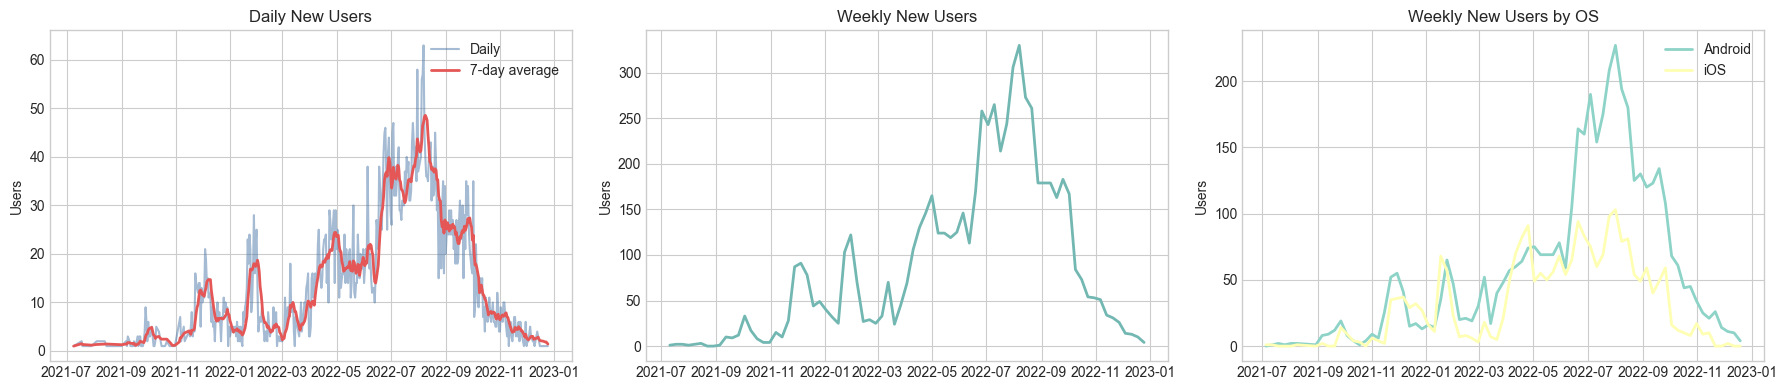

In [34]:
daily_new_users = (
    users_clean
    .groupby('join_date')['user_id']
    .nunique()
    .reset_index(name='new_users')
    .sort_values('join_date')
)
daily_new_users['new_users_7d_ma'] = daily_new_users['new_users'].rolling(7, min_periods=1).mean()

weekly_new_users = (
    daily_new_users
    .set_index('join_date')
    .resample('W')['new_users']
    .sum()
    .reset_index()
)

weekly_new_users_by_os = (
    users_clean
    .assign(join_week=users_clean['join_date'].dt.to_period('W').dt.start_time)
    .groupby(['join_week', 'os'])['user_id']
    .nunique()
    .unstack(fill_value=0)
    .reset_index()
)

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

axes[0].plot(daily_new_users['join_date'], daily_new_users['new_users'], color='#4C78A8', alpha=0.5, label='Daily')
axes[0].plot(daily_new_users['join_date'], daily_new_users['new_users_7d_ma'], color='#E45756', linewidth=2, label='7-day average')
axes[0].set_title('Daily New Users')
axes[0].set_ylabel('Users')
axes[0].legend()

axes[1].plot(weekly_new_users['join_date'], weekly_new_users['new_users'], color='#72B7B2', linewidth=2)
axes[1].set_title('Weekly New Users')
axes[1].set_ylabel('Users')

for os_name in ['Android', 'iOS']:
    if os_name in weekly_new_users_by_os.columns:
        axes[2].plot(weekly_new_users_by_os['join_week'], weekly_new_users_by_os[os_name], linewidth=2, label=os_name)
axes[2].set_title('Weekly New Users by OS')
axes[2].set_ylabel('Users')
axes[2].legend()

plt.tight_layout()
plt.show()


### Comment

- This chart shows join dates for users in this dataset. It is not a full acquisition history. The session window is June 2, 2022 to December 28, 2022, so older join dates can have survivorship bias.
- In this observed sample, join-date volume is very low in the early part of the timeline, then it starts to grow more clearly from around May 2022. The strongest period is in July, August, and early September 2022. After the peak, the volume goes down step by step and becomes much lower near the end of the period.
- Android brings more new users in most weeks, and the biggest peak also comes mainly from Android. iOS follows a similar trend, but at a lower level.


## 5. Session overview

This section shows the main engagement numbers from the session table.


,metric,value
0,total sessions,"1,699,352"
1,unique active users,"6,422"
2,avg sessions per active user,264.61
3,median sessions per active user,192.00
4,total playtime (hours),"316,345.73"
5,avg session duration (min),11.17
6,median session duration (min),4.33


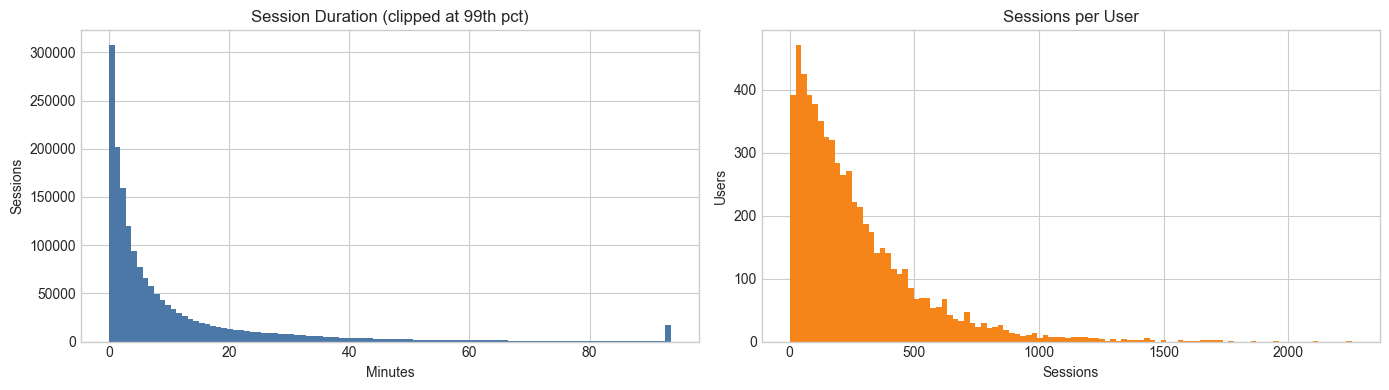

In [35]:
sessions_per_user = sessions_clean.groupby('user_id').size()
session_duration_min = sessions_clean['session_duration_sec'] / 60

session_overview_df = pd.DataFrame(
    {
        'metric': [
            'total sessions',
            'unique active users',
            'avg sessions per active user',
            'median sessions per active user',
            'total playtime (hours)',
            'avg session duration (min)',
            'median session duration (min)',
        ],
        'value': [
            len(sessions_clean),
            sessions_clean['user_id'].nunique(dropna=True),
            sessions_per_user.mean(),
            sessions_per_user.median(),
            sessions_clean['session_duration_sec'].sum() / 3600,
            session_duration_min.mean(),
            session_duration_min.median(),
        ],
    }
)

session_overview_display_df = session_overview_df.copy()
session_overview_display_df['value'] = session_overview_display_df.apply(
    lambda row: f"{row['value']:,.0f}" if row['metric'] in ['total sessions', 'unique active users'] else f"{row['value']:,.2f}",
    axis=1,
)

display(session_overview_display_df)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(session_duration_min.clip(upper=session_duration_min.quantile(0.99)), bins=100, color='#4C78A8')
axes[0].set_title('Session Duration (clipped at 99th pct)')
axes[0].set_xlabel('Minutes')
axes[0].set_ylabel('Sessions')

axes[1].hist(sessions_per_user, bins=100, color='#F58518')
axes[1].set_title('Sessions per User')
axes[1].set_xlabel('Sessions')
axes[1].set_ylabel('Users')

plt.tight_layout()
plt.show()


### Comment

- The game has a high session volume: 1.7M sessions from 6,422 active users.
- The session duration chart is strongly right-skewed. Most sessions are short, and the number of sessions drops fast as duration gets longer.
- Even after clipping at the 99th percentile, I can still see a long tail. This means a smaller group of sessions is much longer than the rest.
- The average session duration and total playtime in the KPI table use raw session values. Very long sessions are still included, so these numbers can be a bit higher because of outliers found in the data quality notebook.
- The `Sessions per User` chart shows the same pattern. Many users have a lower number of sessions, while a smaller group has very high session counts. So this user base is not balanced. A more engaged group likely drives a large share of total activity.


## 6. Daily engagement trend

Here I look at the daily product activity level.


,metric,value
0,avg DAU,"2,822.43"
1,median DAU,"2,891.50"
2,max DAU,"3,539.00"
3,avg sessions per DAU,2.87
4,avg playtime per DAU (min),31.59


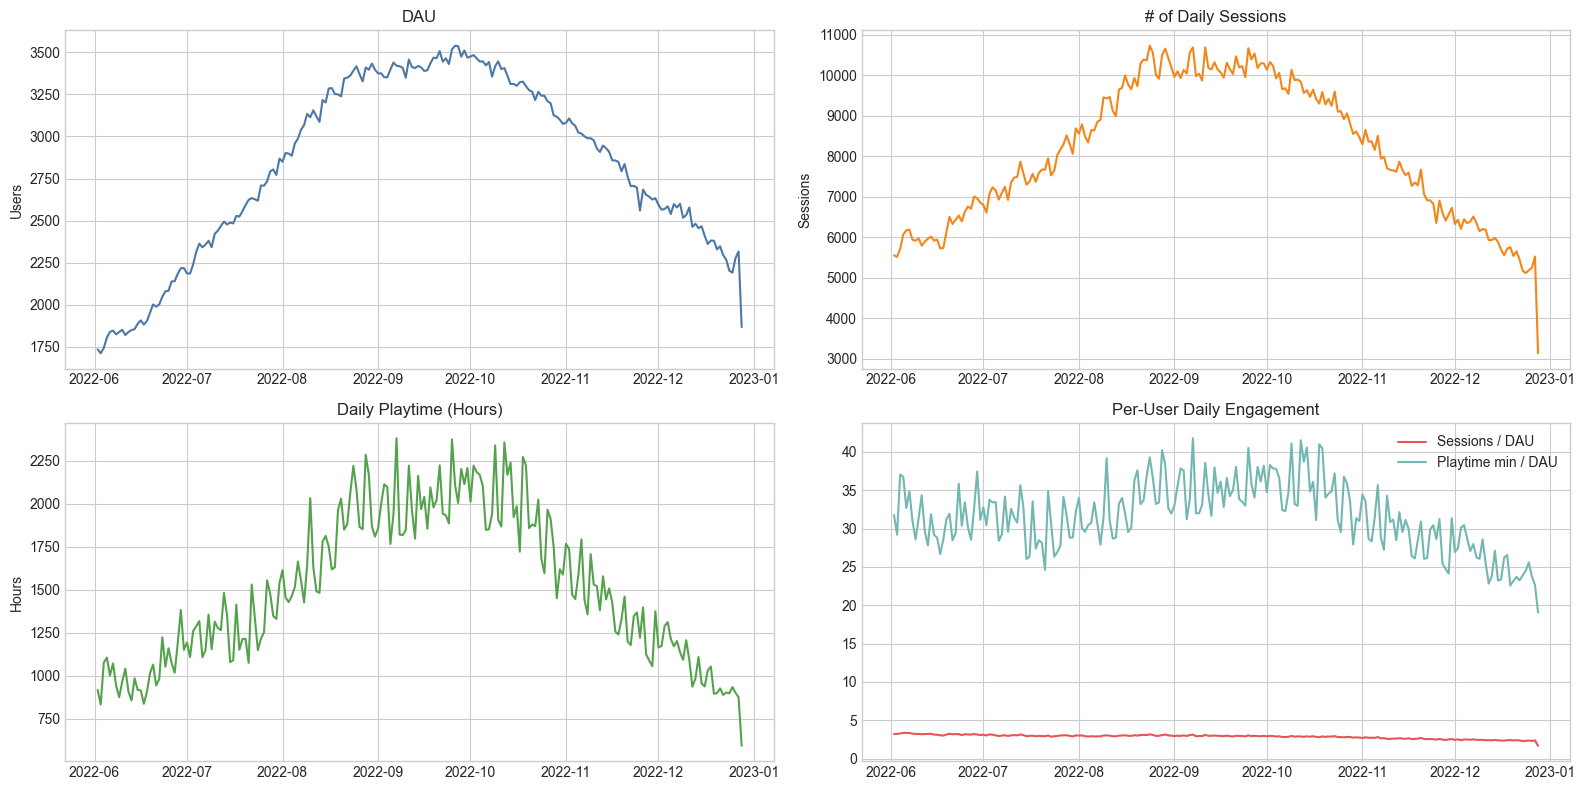

In [36]:
daily_engagement = (
    sessions_clean
    .groupby('dt')
    .agg(
        dau=('user_id', 'nunique'),
        sessions=('session_id', 'size'),
        playtime_hours=('session_duration_sec', lambda s: s.sum() / 3600),
    )
    .reset_index()
)

daily_engagement['sessions_per_dau'] = daily_engagement['sessions'] / daily_engagement['dau']
daily_engagement['playtime_min_per_dau'] = (daily_engagement['playtime_hours'] * 60) / daily_engagement['dau']

daily_engagement_summary = pd.DataFrame(
    {
        'metric': [
            'avg DAU',
            'median DAU',
            'max DAU',
            'avg sessions per DAU',
            'avg playtime per DAU (min)',
        ],
        'value': [
            daily_engagement['dau'].mean(),
            daily_engagement['dau'].median(),
            daily_engagement['dau'].max(),
            daily_engagement['sessions_per_dau'].mean(),
            daily_engagement['playtime_min_per_dau'].mean(),
        ],
    }
)

display(daily_engagement_summary)

fig, axes = plt.subplots(2, 2, figsize=(16, 8))

axes[0, 0].plot(daily_engagement['dt'], daily_engagement['dau'], color='#4C78A8')
axes[0, 0].set_title('DAU')
axes[0, 0].set_ylabel('Users')

axes[0, 1].plot(daily_engagement['dt'], daily_engagement['sessions'], color='#F58518')
axes[0, 1].set_title('# of Daily Sessions')
axes[0, 1].set_ylabel('Sessions')

axes[1, 0].plot(daily_engagement['dt'], daily_engagement['playtime_hours'], color='#54A24B')
axes[1, 0].set_title('Daily Playtime (Hours)')
axes[1, 0].set_ylabel('Hours')

axes[1, 1].plot(daily_engagement['dt'], daily_engagement['sessions_per_dau'], color='#E45756', label='Sessions / DAU')
axes[1, 1].plot(daily_engagement['dt'], daily_engagement['playtime_min_per_dau'], color='#72B7B2', label='Playtime min / DAU')
axes[1, 1].set_title('Per-User Daily Engagement')
axes[1, 1].legend()

plt.tight_layout()
plt.show()


### Comment

- DAU, daily sessions, and daily playtime all follow a similar pattern. They grow from June to around September, then they go down step by step until the end of the period. This means the product was strongest around late summer and early autumn, then daily activity became weaker in the last months of the dataset.
- `Sessions / DAU` looks quite stable, so the number of sessions per active user does not change much over time.
- `Playtime min / DAU` changes more than `Sessions / DAU`. It is higher around September and October, then it goes down in November and December. This suggests active users still open the game at a similar rate, but they spend less time in the game near the end of the period.

## 7. Active day distribution

A simple way to read engagement is to check on how many different days users were active.


,metric,value
0,registered users,6584
1,active users,6422
2,users with no sessions,162


,active_day_segment,users,user_share
0,1 day,37,0.01
1,2-3 days,49,0.01
2,4-7 days,139,0.02
3,8+ days,6197,0.96


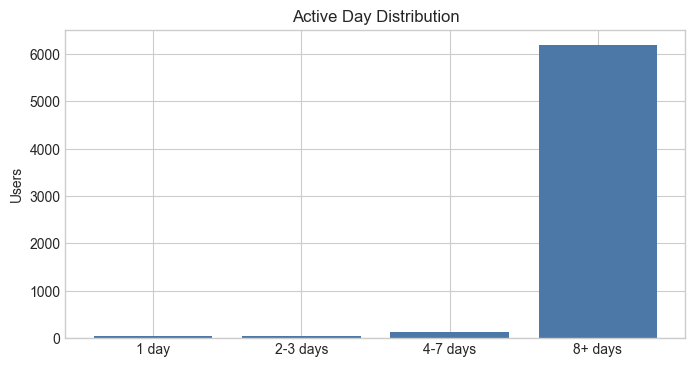

In [37]:
active_days_per_user = sessions_clean.groupby('user_id')['dt'].nunique()
no_session_users = users_clean['user_id'].nunique() - active_days_per_user.index.nunique()

active_day_segment = pd.cut(
    active_days_per_user,
    bins=[0, 1, 3, 7, np.inf],
    labels=['1 day', '2-3 days', '4-7 days', '8+ days'],
    include_lowest=True,
)

active_day_dist = (
    active_day_segment
    .value_counts()
    .sort_index()
    .rename_axis('active_day_segment')
    .reset_index(name='users')
)
active_day_dist['user_share'] = active_day_dist['users'] / active_day_dist['users'].sum()

coverage_df = pd.DataFrame(
    {
        'metric': ['registered users', 'active users', 'users with no sessions'],
        'value': [
            users_clean['user_id'].nunique(dropna=True),
            sessions_clean['user_id'].nunique(dropna=True),
            no_session_users,
        ],
    }
)

display(coverage_df)
display(active_day_dist)

plt.figure(figsize=(8, 4))
plt.bar(active_day_dist['active_day_segment'], active_day_dist['users'], color='#4C78A8')
plt.title('Active Day Distribution')
plt.ylabel('Users')
plt.show()


### Comment

- There are 162 users in `users`, but they do not have any session in the session table.
- Among active users, most users are in the `8+ days` group. This means the observed session base is not only one-time visitors. It is mostly users with repeated activity.

## 8. User-level engagement table

Now I build a simple user-level table. I will use this again in the next notebooks.


In [38]:
user_summary = (
    users_clean[['user_id', 'join_date', 'os', 'country']]
    .merge(
        sessions_clean
        .groupby('user_id')
        .agg(
            total_sessions=('session_id', 'size'),
            total_playtime_sec=('session_duration_sec', 'sum'),
            active_days=('dt', 'nunique'),
            avg_session_duration_sec=('session_duration_sec', 'mean'),
            first_session_date=('dt', 'min'),
            last_session_date=('dt', 'max'),
            max_level_completed=('level_completed', 'max'),
        )
        .reset_index(),
        on='user_id',
        how='left'
    )
)

for col in ['total_sessions', 'total_playtime_sec', 'active_days', 'avg_session_duration_sec']:
    user_summary[col] = user_summary[col].fillna(0)

user_summary['observed_lifetime_days'] = (
    user_summary['last_session_date'] - user_summary['first_session_date']
).dt.days.add(1)
user_summary['observed_lifetime_days'] = user_summary['observed_lifetime_days'].fillna(0)

user_summary['total_sessions'] = user_summary['total_sessions'].astype(int)
user_summary['active_days'] = user_summary['active_days'].astype(int)
user_summary['total_playtime_hours'] = user_summary['total_playtime_sec'] / 3600
user_summary['avg_session_duration_min'] = user_summary['avg_session_duration_sec'] / 60

if 'max_level_completed' in user_summary.columns:
    user_summary['max_level_completed'] = user_summary['max_level_completed'].astype('Int64')

user_summary_view = user_summary[
    [
        'user_id',
        'join_date',
        'os',
        'country',
        'total_sessions',
        'total_playtime_hours',
        'active_days',
        'avg_session_duration_min',
        'first_session_date',
        'last_session_date',
        'observed_lifetime_days',
        'max_level_completed',
    ]
]

display(user_summary_view.head(10))


,user_id,join_date,os,country,total_sessions,total_playtime_hours,active_days,avg_session_duration_min,first_session_date,last_session_date,observed_lifetime_days,max_level_completed
0,157844,2021-12-05,Android,United States,524,72.68,141,8.32,2022-06-30,2022-12-28,182.00,6
1,583785,2022-06-25,iOS,Germany,9,4.48,2,29.84,2022-06-25,2022-06-26,2.00,27
2,152828,2021-12-04,iOS,United States,0,0.00,0,0.00,NaT,NaT,0.00,<NA>
3,948940,2022-09-19,Android,Spain,4,3.20,3,48.05,2022-09-19,2022-09-25,7.00,7
4,1141021,2022-12-25,Android,Austria,11,15.67,4,85.50,2022-12-25,2022-12-28,4.00,11
5,535442,2022-06-03,Android,Italy,78,12.07,36,9.29,2022-06-03,2022-11-07,158.00,14
6,910913,2022-09-09,Android,United States,21,6.47,5,18.48,2022-09-09,2022-09-13,5.00,8
7,695371,2022-07-28,Android,Poland,425,136.02,49,19.20,2022-07-28,2022-11-07,103.00,29
8,159017,2021-12-06,Android,United States,56,18.07,32,19.36,2022-08-08,2022-10-10,64.00,12
9,721930,2022-08-02,Android,United States,16,5.28,15,19.82,2022-08-02,2022-11-25,116.00,4


### Comment

- This table gives one row per user, so it is useful for later segmentation work.
- It keeps both volume metrics (`total_sessions`, `total_playtime_hours`) and time metrics (`active_days`, `observed_lifetime_days`).
- Users with no session stay in the table with zero values. This is important because they are still part of the registered user base.


## 9. Country comparison

Now I compare engagement across the biggest countries in the user base.


,country,users,avg_sessions_per_user,avg_playtime_hours,avg_active_days
0,United Kingdom,1531,273.76,42.78,101.38
1,United States,1439,219.78,44.08,84.46
2,Germany,418,272.06,49.03,91.79
3,Spain,260,361.77,73.97,104.19
4,Chile,237,332.73,65.55,106.60
5,Italy,189,272.62,51.02,84.87
6,France,187,205.36,39.54,79.39
7,Poland,145,245.23,48.33,80.88
8,Canada,130,235.70,41.72,89.65
9,Brazil,121,213.36,46.88,69.74


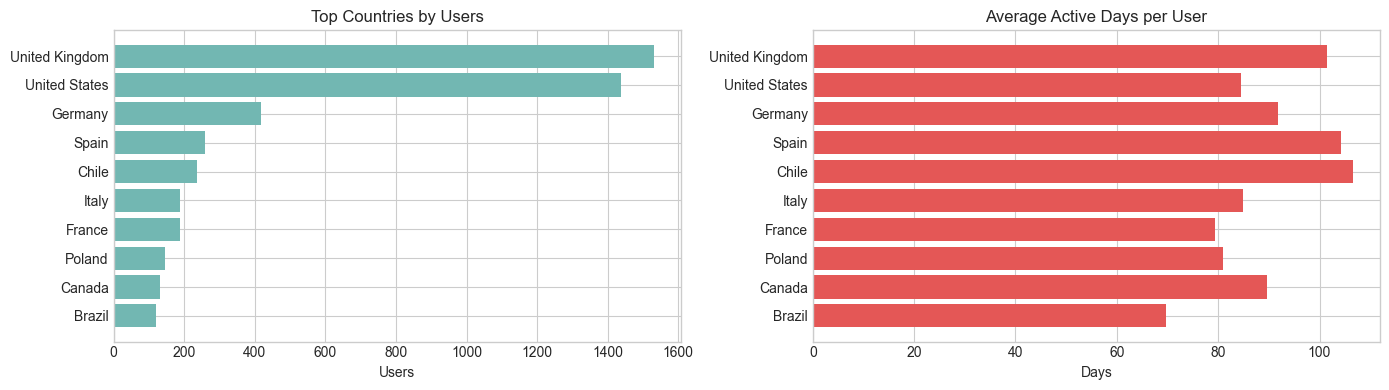

In [39]:
top_countries = user_summary['country'].value_counts().head(10).index

country_engagement = (
    user_summary[user_summary['country'].isin(top_countries)]
    .groupby('country')
    .agg(
        users=('user_id', 'nunique'),
        avg_sessions_per_user=('total_sessions', 'mean'),
        avg_playtime_hours=('total_playtime_hours', 'mean'),
        avg_active_days=('active_days', 'mean'),
    )
    .sort_values('users', ascending=False)
    .reset_index()
)

display(country_engagement)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].barh(country_engagement['country'][::-1], country_engagement['users'][::-1], color='#72B7B2')
axes[0].set_title('Top Countries by Users')
axes[0].set_xlabel('Users')

axes[1].barh(country_engagement['country'][::-1], country_engagement['avg_active_days'][::-1], color='#E45756')
axes[1].set_title('Average Active Days per User')
axes[1].set_xlabel('Days')

plt.tight_layout()
plt.show()


### Comment

- The United Kingdom and the United States are the biggest countries by user count.
- Bigger user count does not always mean stronger engagement. For example, Spain and Chile show stronger average activity than some larger countries.

## 10. OS comparison

This section shows if Android and iOS users behave differently.


,os,users,avg_sessions_per_user,avg_playtime_hours,avg_active_days,median_session_duration_min
0,Android,4266,242.00,47.17,86.99,4.82
1,iOS,2318,287.75,49.66,95.61,3.63


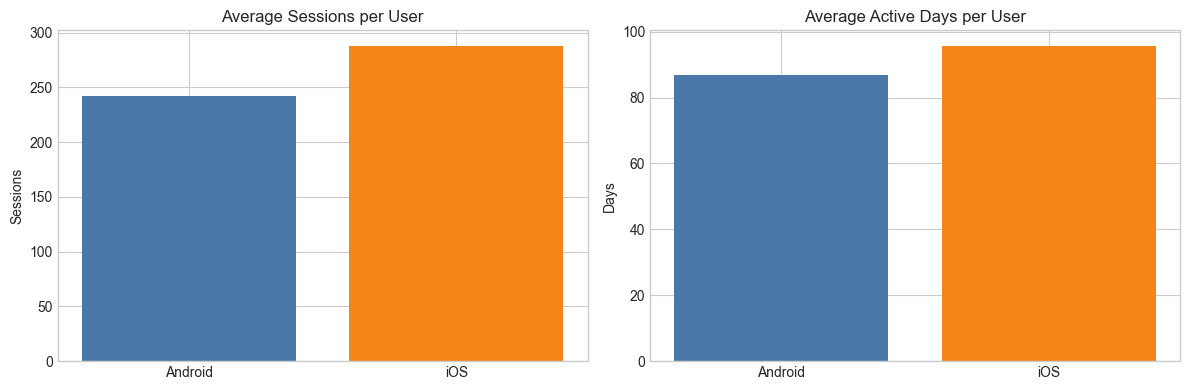

In [40]:
session_os = sessions_clean.merge(users_clean[['user_id', 'os']], on='user_id', how='left')

os_engagement = (
    user_summary
    .groupby('os')
    .agg(
        users=('user_id', 'nunique'),
        avg_sessions_per_user=('total_sessions', 'mean'),
        avg_playtime_hours=('total_playtime_hours', 'mean'),
        avg_active_days=('active_days', 'mean'),
    )
    .reset_index()
)

os_median_session = (
    session_os
    .groupby('os')['session_duration_sec']
    .median()
    .div(60)
    .rename('median_session_duration_min')
    .reset_index()
)

os_engagement = os_engagement.merge(os_median_session, on='os', how='left')
display(os_engagement)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(os_engagement['os'], os_engagement['avg_sessions_per_user'], color=['#4C78A8', '#F58518'])
axes[0].set_title('Average Sessions per User')
axes[0].set_ylabel('Sessions')

axes[1].bar(os_engagement['os'], os_engagement['avg_active_days'], color=['#4C78A8', '#F58518'])
axes[1].set_title('Average Active Days per User')
axes[1].set_ylabel('Days')

plt.tight_layout()
plt.show()


### Comment

- Android has more users, but iOS users show higher average sessions and active days per user.
- At the same time, Android has a longer median session duration. So the platform gap is not one simple story. iOS looks more frequent, while Android sessions look a bit longer.


## 11. New users and early engagement

I want to see how early user behavior looks. For the first 7-day view, I use only users who have a full 7-day observation window inside the session data period.


In [41]:
eligible_new_users = users_clean[
    users_clean['join_date'].between(session_start, session_end - pd.Timedelta(days=6))
].copy()

sessions_with_join = sessions_clean.merge(
    users_clean[['user_id', 'join_date']],
    on='user_id',
    how='left'
)
sessions_with_join['days_since_join'] = (sessions_with_join['dt'] - sessions_with_join['join_date']).dt.days

first_7d = (
    sessions_with_join[sessions_with_join['days_since_join'].between(0, 6)]
    .groupby('user_id')
    .agg(
        first_7d_sessions=('session_id', 'size'),
        first_7d_playtime_hours=('session_duration_sec', lambda s: s.sum() / 3600),
        first_7d_active_days=('dt', 'nunique'),
    )
    .reset_index()
)

first_7d_summary = (
    eligible_new_users[['user_id']]
    .merge(first_7d, on='user_id', how='left')
    .fillna(0)
)

first_7d_kpi = pd.DataFrame(
    {
        'metric': [
            'eligible new users',
            'avg first 7d sessions',
            'median first 7d sessions',
            'avg first 7d playtime (hours)',
            'avg first 7d active days',
        ],
        'value': [
            len(first_7d_summary),
            first_7d_summary['first_7d_sessions'].mean(),
            first_7d_summary['first_7d_sessions'].median(),
            first_7d_summary['first_7d_playtime_hours'].mean(),
            first_7d_summary['first_7d_active_days'].mean(),
        ],
    }
)

first_7d_summary['first_7d_active_segment'] = pd.cut(
    first_7d_summary['first_7d_active_days'],
    bins=[-0.1, 0, 1, 3, 7],
    labels=['0 day', '1 day', '2-3 days', '4-7 days'],
)
first_7d_segment = (
    first_7d_summary['first_7d_active_segment']
    .value_counts()
    .sort_index()
    .rename_axis('segment')
    .reset_index(name='users')
)

stage_daily = (
    sessions_with_join
    .assign(user_type=np.where(sessions_with_join['days_since_join'].between(0, 6), 'New users (day 0-6)', 'Existing users (day 7+)'))
    .groupby(['dt', 'user_type'])
    .agg(
        active_users=('user_id', 'nunique'),
        sessions=('session_id', 'size'),
        playtime_min=('session_duration_sec', lambda s: s.sum() / 60),
    )
    .reset_index()
)
stage_daily['sessions_per_active_user'] = stage_daily['sessions'] / stage_daily['active_users']
stage_daily['playtime_min_per_active_user'] = stage_daily['playtime_min'] / stage_daily['active_users']

stage_compare = (
    stage_daily
    .groupby('user_type')
    .agg(
        avg_daily_active_users=('active_users', 'mean'),
        avg_sessions_per_active_user=('sessions_per_active_user', 'mean'),
        avg_playtime_min_per_active_user=('playtime_min_per_active_user', 'mean'),
    )
    .reset_index()
)

display(first_7d_kpi)
display(stage_compare)

,metric,value
0,eligible new users,"4,266.00"
1,avg first 7d sessions,21.96
2,median first 7d sessions,19.00
3,avg first 7d playtime (hours),5.53
4,avg first 7d active days,6.04


,user_type,avg_daily_active_users,avg_sessions_per_active_user,avg_playtime_min_per_active_user
0,Existing users (day 7+),"2,698.29",2.84,30.54
1,New users (day 0-6),124.14,3.57,60.92


### Comment

- For users with a full 7-day observation window, early engagement looks quite strong. Most eligible new users are active on 4 to 7 different days in their first week.
- When I compare daily behavior, new users open the game more often and spend more minutes per active user than existing users.


## 12. Weekday pattern

This dataset has only daily dates, not hour-level timestamps. So here I only check weekday patterns.


,weekday,sessions,active_users
0,Monday,243931,6286
1,Tuesday,245221,6281
2,Wednesday,243597,6278
3,Thursday,241997,6305
4,Friday,240383,6287
5,Saturday,237395,6286
6,Sunday,246828,6296


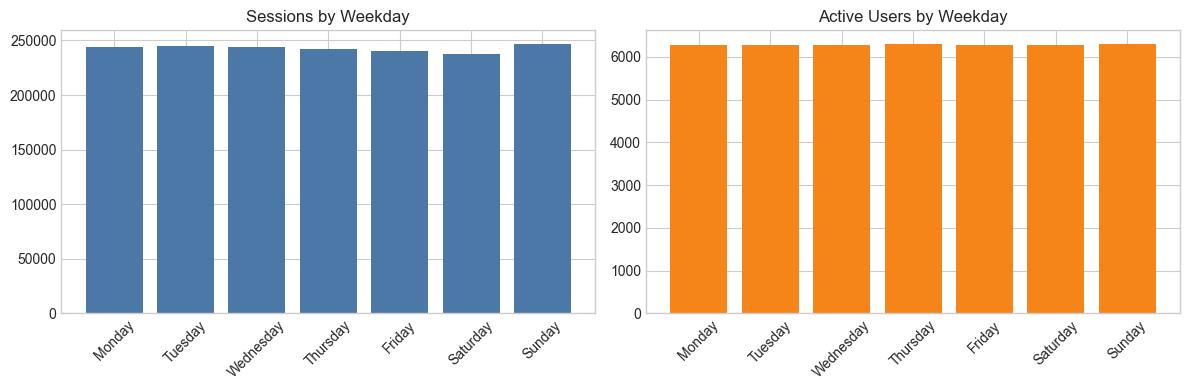

In [42]:
weekday_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

weekday_summary = (
    sessions_clean
    .assign(weekday=sessions_clean['dt'].dt.day_name())
    .groupby('weekday')
    .agg(
        sessions=('session_id', 'size'),
        active_users=('user_id', 'nunique'),
    )
    .reindex(weekday_order)
    .reset_index()
)

display(weekday_summary)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(weekday_summary['weekday'], weekday_summary['sessions'], color='#4C78A8')
axes[0].set_title('Sessions by Weekday')
axes[0].tick_params(axis='x', rotation=45)

axes[1].bar(weekday_summary['weekday'], weekday_summary['active_users'], color='#F58518')
axes[1].set_title('Active Users by Weekday')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


### Comment

- Weekday activity looks fairly balanced. Sunday is slightly higher than some other days, but the gap is not very large.

## 13. Small progression preview

This is not a full progression notebook, but I still want a small look at level data next to engagement.


,metric,value
0,active users,"6,422.00"
1,users with any level data,"6,366.00"
2,share of active users with level data,0.99


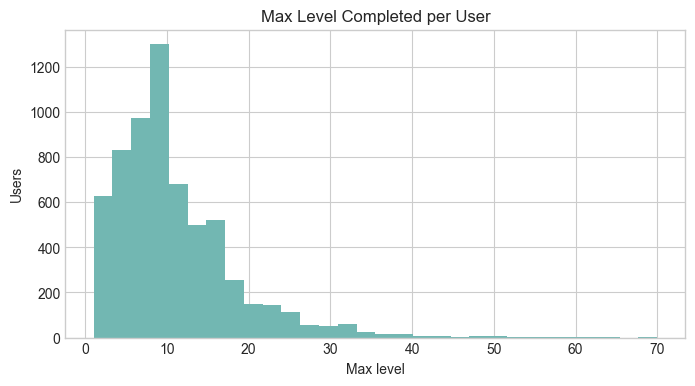

In [43]:
level_coverage_df = pd.DataFrame(
    {
        'metric': ['active users', 'users with any level data', 'share of active users with level data'],
        'value': [
            sessions_clean['user_id'].nunique(dropna=True),
            sessions_clean.loc[sessions_clean['level_completed'].notna(), 'user_id'].nunique(dropna=True),
            sessions_clean.loc[sessions_clean['level_completed'].notna(), 'user_id'].nunique(dropna=True) / sessions_clean['user_id'].nunique(dropna=True),
        ],
    }
)

level_user_summary = (
    sessions_clean
    .groupby('user_id')
    .agg(
        total_sessions=('session_id', 'size'),
        max_level_completed=('level_completed', 'max'),
    )
    .reset_index()
)

level_user_summary['session_band'] = pd.cut(
    level_user_summary['total_sessions'],
    bins=[0, 10, 50, 200, np.inf],
    labels=['1-10', '11-50', '51-200', '200+'],
    include_lowest=True,
)

display(level_coverage_df)

plt.figure(figsize=(8, 4))
plt.hist(level_user_summary['max_level_completed'].dropna(), bins=30, color='#72B7B2')
plt.title('Max Level Completed per User')
plt.xlabel('Max level')
plt.ylabel('Users')
plt.show()


### Comment

- The chart shows that most users stay in the lower and middle level range. The biggest group looks around levels 5 to 15.
- There is a long tail, but only a small number of users reach very high levels. So this early view suggests progression is concentrated in the early part of the game, not evenly spread across high levels.

## 14. Key findings

- The user base is spread across many countries, but the United Kingdom and the United States are the main markets.
- New user growth becomes much stronger in summer 2022, peaks around late summer and early autumn, and then goes down in the later months.
- Android has the larger user base, but iOS shows stronger average activity on some engagement metrics.
- Session behavior is not balanced. Most sessions are short, and a smaller user group drives a large share of total activity.
- Daily engagement is strongest around September and October. Later in the period, both volume and playtime per active user become weaker.
- Among active users, most are active on 8 or more days, so the observed session base looks fairly engaged.
- The first 7-day view is also strong for users with a full observation window, which makes it a useful bridge to the retention analysis.
- The small progression view suggests that most users stay in lower and middle levels, while only a small group reaches very high levels.
